## Loan Approval Prediction Using XGBoost: An End-to-End Machine Learning Pipeline

## Import Libraries

In [13]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

import warnings
warnings.filterwarnings('ignore')

## Import Dataset

In [14]:
df = pd.read_csv('train_.csv',index_col=0)
df.head()

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
Loan_ID,,,,,,,,,,,,
LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


## 1. Data Understanding

In [15]:
df.shape

(614, 12)

In [16]:
df.info()

<class 'pandas.DataFrame'>
Index: 614 entries, LP001002 to LP002990
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Gender             601 non-null    str    
 1   Married            611 non-null    str    
 2   Dependents         599 non-null    str    
 3   Education          614 non-null    str    
 4   Self_Employed      582 non-null    str    
 5   ApplicantIncome    614 non-null    int64  
 6   CoapplicantIncome  614 non-null    float64
 7   LoanAmount         592 non-null    float64
 8   Loan_Amount_Term   600 non-null    float64
 9   Credit_History     564 non-null    float64
 10  Property_Area      614 non-null    str    
 11  Loan_Status        614 non-null    str    
dtypes: float64(4), int64(1), str(7)
memory usage: 83.3 KB


In [17]:
df.describe(include=object)

,Gender,Married,Dependents,Education,Self_Employed,Property_Area,Loan_Status
count,601,611,599,614,582,614,614
unique,2,2,4,2,2,3,2
top,Male,Yes,0,Graduate,No,Semiurban,Y
freq,489,398,345,480,500,233,422


In [18]:
df.describe()

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
count,614.000000,614.000000,592.000000,600.00000,564.000000
mean,5403.459283,1621.245798,146.412162,342.00000,0.842199
std,6109.041673,2926.248369,85.587325,65.12041,0.364878
min,150.000000,0.000000,9.000000,12.00000,0.000000
25%,2877.500000,0.000000,100.000000,360.00000,1.000000
50%,3812.500000,1188.500000,128.000000,360.00000,1.000000
75%,5795.000000,2297.250000,168.000000,360.00000,1.000000
max,81000.000000,41667.000000,700.000000,480.00000,1.000000


## 2. Data Cleaning & Missing Value Treatment

In [19]:
df.isna().sum()

Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64

In [20]:
df.isna().sum()/df.shape[0]*100

Gender               2.117264
Married              0.488599
Dependents           2.442997
Education            0.000000
Self_Employed        5.211726
ApplicantIncome      0.000000
CoapplicantIncome    0.000000
LoanAmount           3.583062
Loan_Amount_Term     2.280130
Credit_History       8.143322
Property_Area        0.000000
Loan_Status          0.000000
dtype: float64

In [21]:
cols = df.isna().sum()[df.isna().sum() > 0].index
cols

Index(['Gender', 'Married', 'Dependents', 'Self_Employed', 'LoanAmount',
       'Loan_Amount_Term', 'Credit_History'],
      dtype='str')

In [22]:
for  i in cols:
    print(f"{i} : {df[i].unique()}")

Gender : <ArrowStringArray>
['Male', 'Female', nan]
Length: 3, dtype: str
Married : <ArrowStringArray>
['No', 'Yes', nan]
Length: 3, dtype: str
Dependents : <ArrowStringArray>
['0', '1', '2', '3+', nan]
Length: 5, dtype: str
Self_Employed : <ArrowStringArray>
['No', 'Yes', nan]
Length: 3, dtype: str
LoanAmount : [ nan 128.  66. 120. 141. 267.  95. 158. 168. 349.  70. 109. 200. 114.
  17. 125. 100.  76. 133. 115. 104. 315. 116. 112. 151. 191. 122. 110.
  35. 201.  74. 106. 320. 144. 184.  80.  47.  75. 134.  96.  88.  44.
 286.  97. 135. 180.  99. 165. 258. 126. 312. 136. 172.  81. 187. 113.
 176. 130. 111. 167. 265.  50. 210. 175. 131. 188.  25. 137. 160. 225.
 216.  94. 139. 152. 118. 185. 154.  85. 259. 194.  93. 370. 182. 650.
 102. 290.  84. 242. 129.  30. 244. 600. 255.  98. 275. 121.  63. 700.
  87. 101. 495.  67.  73. 260. 108.  58.  48. 164. 170.  83.  90. 166.
 124.  55.  59. 127. 214. 240.  72.  60. 138.  42. 280. 140. 155. 123.
 279. 192. 304. 330. 150. 207. 436.  78.  54.  

In [23]:
from pandas.api.types import is_numeric_dtype

for col in cols:
    if is_numeric_dtype(df[col]):
        df[col] = df[col].fillna(df[col].mean())
    else:
        df[col] = df[col].fillna(df[col].mode()[0])

In [24]:
df.isna().sum()

Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
Loan_Status          0
dtype: int64

## 3. Exploratory Data Analysis


<Axes: xlabel='Dependents'>

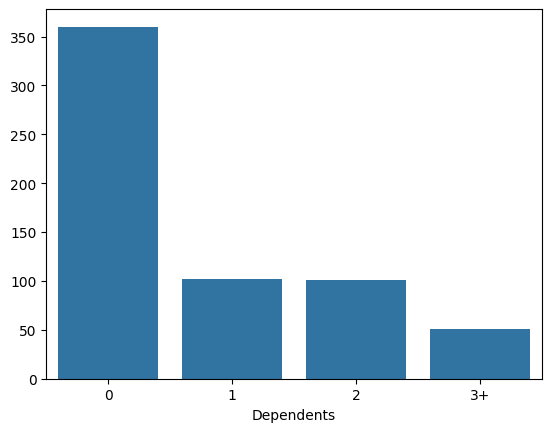

In [25]:
sns.barplot(x=df['Dependents'].value_counts().index, y=df['Dependents'].value_counts().values)

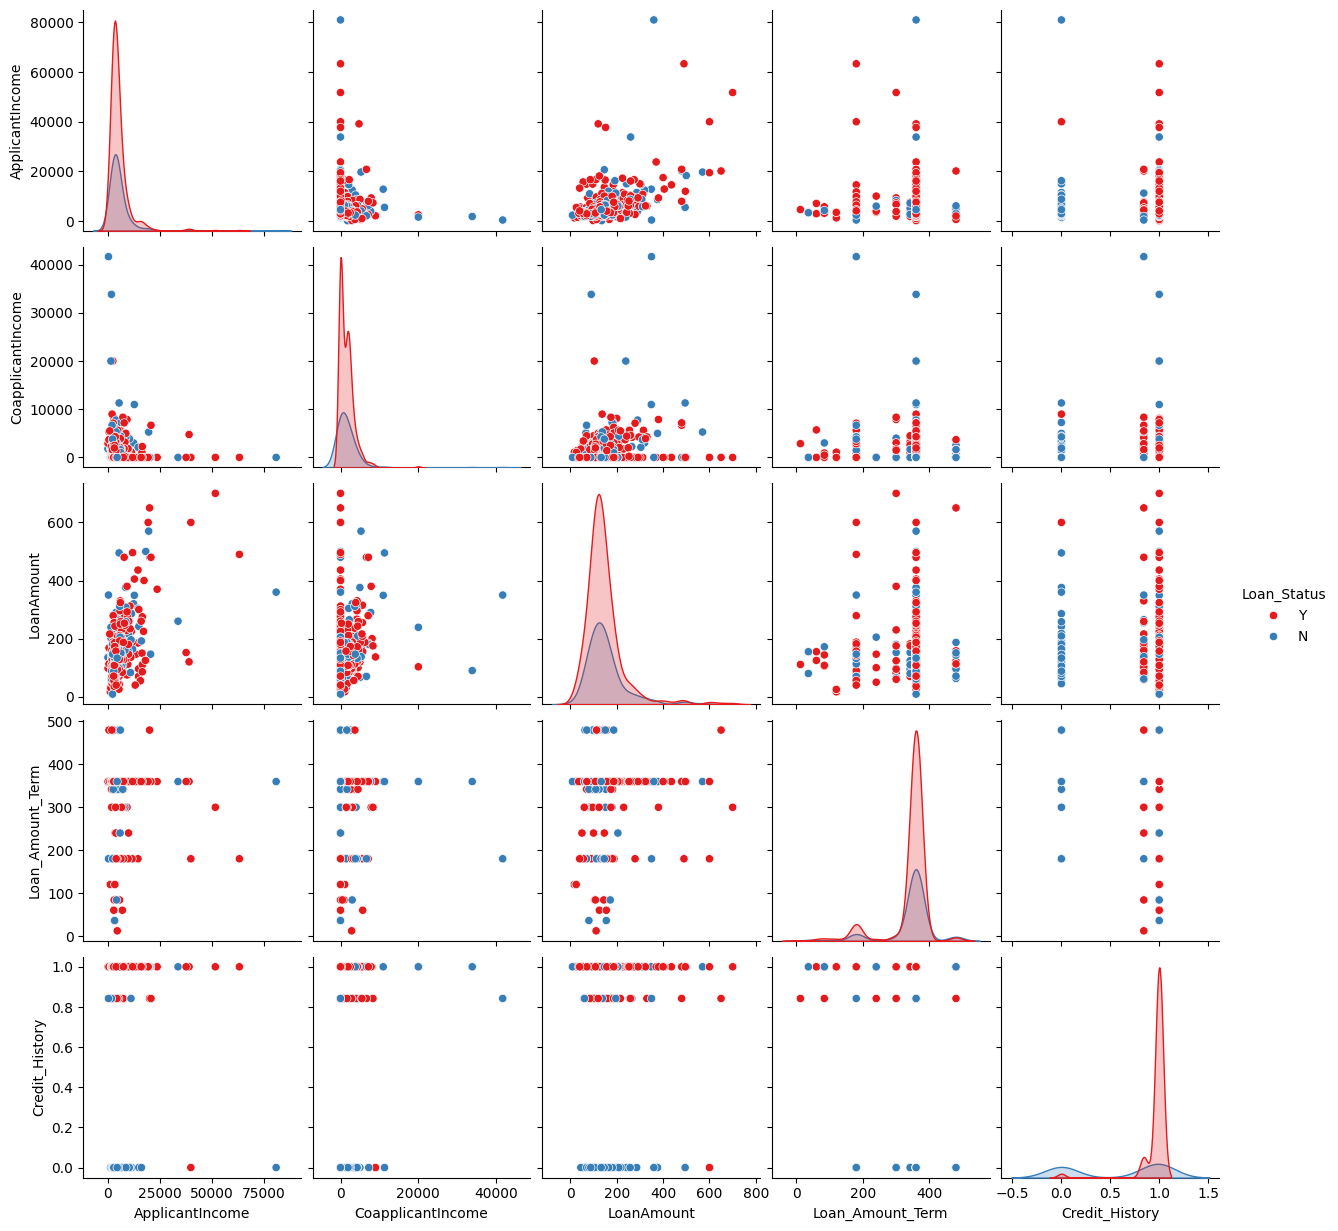

In [26]:
sns.pairplot(df, hue='Loan_Status', palette='Set1')

<Axes: xlabel='Self_Employed'>

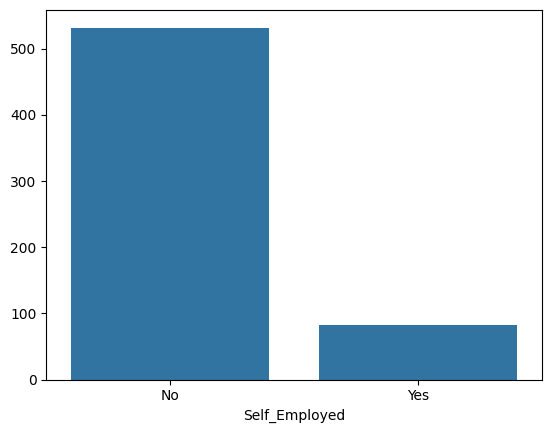

In [27]:
sns.barplot(x=df['Self_Employed'].value_counts().index, y=df['Self_Employed'].value_counts().values)

<Axes: >

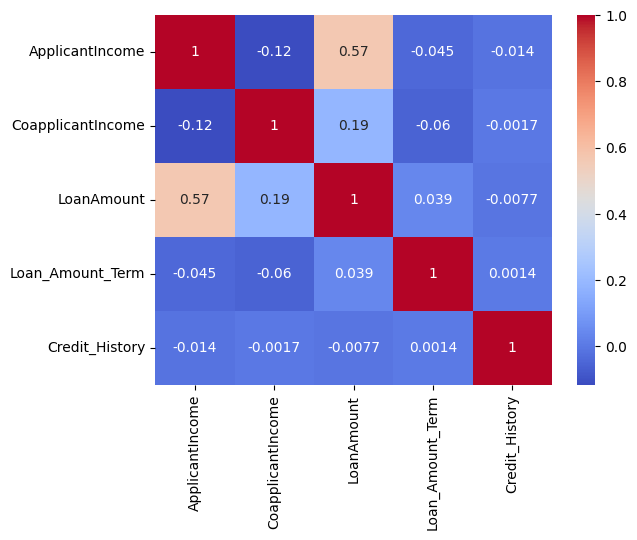

In [28]:
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')

## 4. Outlier Detection


<Axes: >

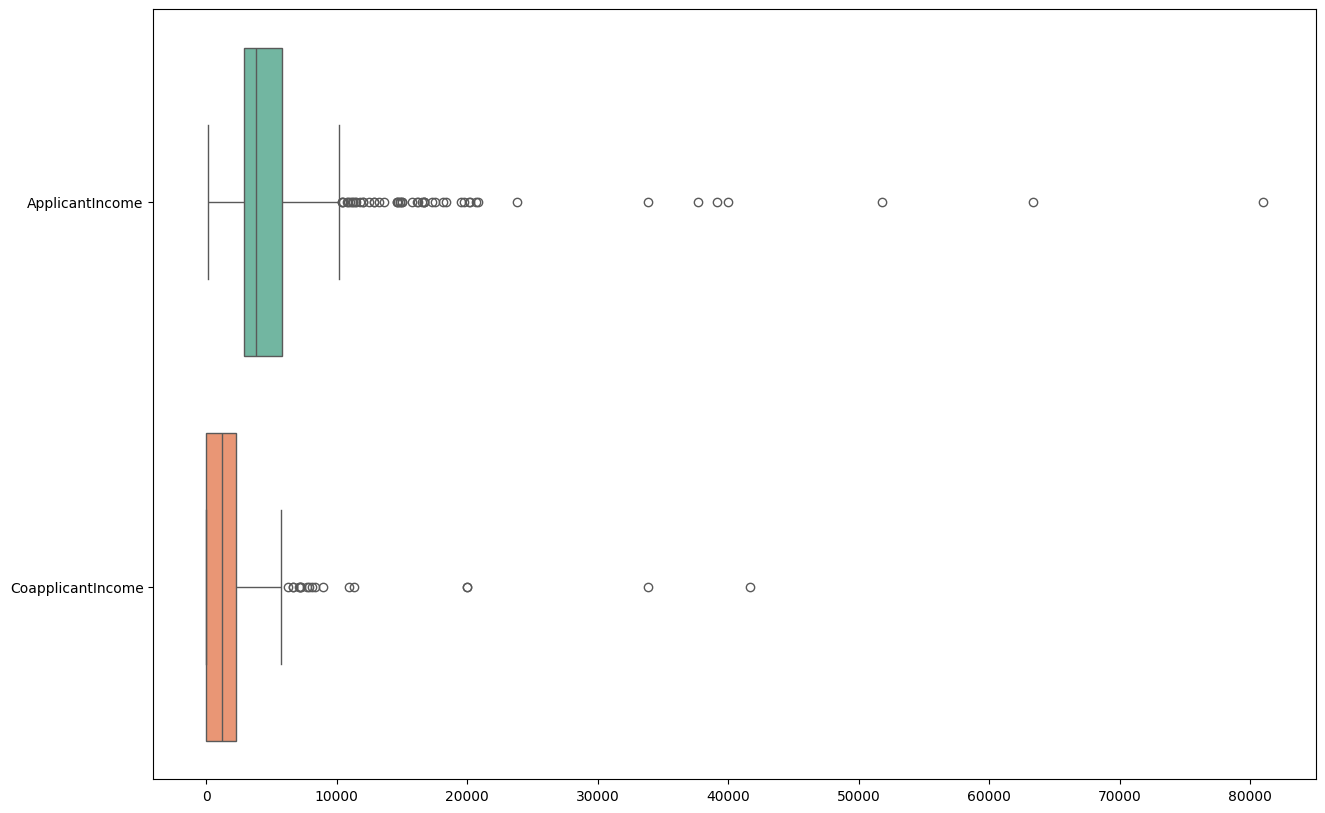

In [29]:
plt.figure(figsize=(15,10))
sns.boxplot(data=df[['ApplicantIncome', 'CoapplicantIncome']], orient='h', palette='Set2')

<Axes: >

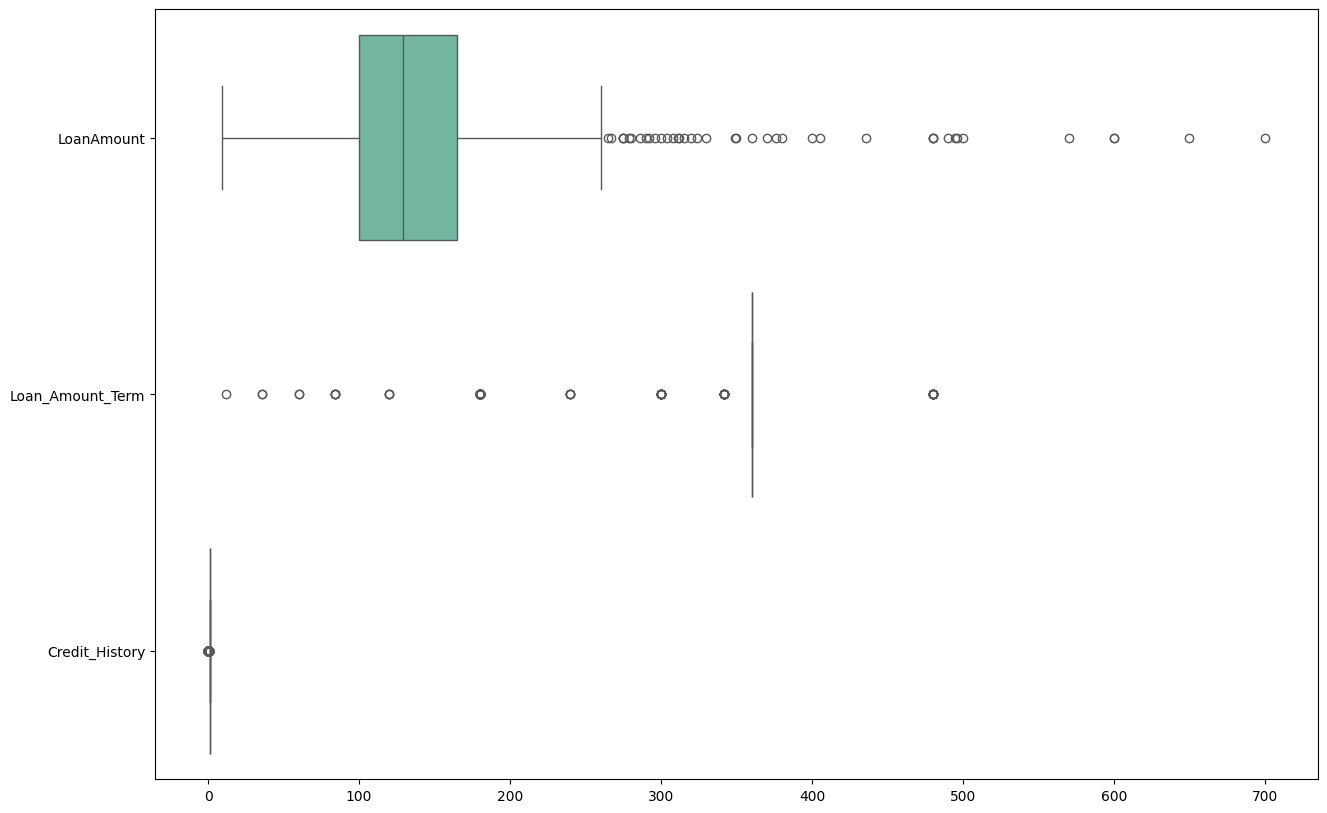

In [30]:
plt.figure(figsize=(15,10))
sns.boxplot(data=df[['LoanAmount','Loan_Amount_Term','Credit_History']], orient='h', palette='Set2')

## 5. Encoding Categorical Features


In [31]:
col = df.select_dtypes(include='object').columns
col

Index(['Gender', 'Married', 'Dependents', 'Education', 'Self_Employed',
       'Property_Area', 'Loan_Status'],
      dtype='str')

In [32]:
for i in col:
    print(f"{i} : {df[i].unique()}")

Gender : <ArrowStringArray>
['Male', 'Female']
Length: 2, dtype: str
Married : <ArrowStringArray>
['No', 'Yes']
Length: 2, dtype: str
Dependents : <ArrowStringArray>
['0', '1', '2', '3+']
Length: 4, dtype: str
Education : <ArrowStringArray>
['Graduate', 'Not Graduate']
Length: 2, dtype: str
Self_Employed : <ArrowStringArray>
['No', 'Yes']
Length: 2, dtype: str
Property_Area : <ArrowStringArray>
['Urban', 'Rural', 'Semiurban']
Length: 3, dtype: str
Loan_Status : <ArrowStringArray>
['Y', 'N']
Length: 2, dtype: str


In [33]:
# Binary Encoding
df['Gender'] = df['Gender'].map({'Male': 1, 'Female': 0})

df['Married'] = df['Married'].map({'Yes': 1, 'No': 0})

df['Education'] = df['Education'].map({'Graduate': 1, 'Not Graduate': 0})

df['Self_Employed'] = df['Self_Employed'].map({'Yes': 1, 'No': 0})

# Ordinal Encoding
df['Dependents'] = df['Dependents'].map({'0': 0,'1': 1,'2': 2,'3+': 3})

# One-Hot Encoding
df = pd.get_dummies(df, columns=['Property_Area'], drop_first=True)

# Target Encoding
df['Loan_Status'] = df['Loan_Status'].map({'Y': 1,'N': 0})

## 6. Feature Selection


In [34]:
X = df.drop('Loan_Status', axis=1)
y = df["Loan_Status"]

## 7. Train-Test Split


In [35]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## 8. Handle Class Imbalance (SMOTE)


In [36]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(X_train,y_train)

## 9. Baseline Models

In [37]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42)
}

for name, model in models.items():
    model.fit(X_train_smote, y_train_smote)
    print(f"{name}: {model.score(X_test, y_test):.4f}")

Logistic Regression: 0.7398
Decision Tree: 0.7154
Random Forest: 0.7724


## 10. XGBoost Model


In [38]:
from xgboost import XGBClassifier

xgb = XGBClassifier(random_state=42,eval_metric='logloss')

xgb.fit(X_train_smote, y_train_smote)

print("XGBoost:", xgb.score(X_test, y_test))

XGBoost: 0.7723577235772358


## 11. Hyperparameter Tuning


In [39]:
from sklearn.model_selection import RandomizedSearchCV

param_dist = {
    'n_estimators': [100, 200, 300, 500],
    'max_depth': [3, 4, 5, 6, 8, 10],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'subsample': [0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.7, 0.8, 0.9, 1.0],
    'gamma': [0, 0.1, 0.2, 0.3],
    'min_child_weight': [1, 3, 5, 7]
}

random_search = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=param_dist,
    n_iter=50,
    scoring='accuracy',   # or 'f1', 'roc_auc'
    cv=5,
    verbose=2,
    random_state=42,
    n_jobs=-1
)

random_search.fit(X_train_smote, y_train_smote)

print("Best Parameters:")
print(random_search.best_params_)

print("\nBest CV Score:")
print(random_search.best_score_)

Fitting 5 folds for each of 50 candidates, totalling 250 fits
Best Parameters:
{'subsample': 0.9, 'n_estimators': 100, 'min_child_weight': 1, 'max_depth': 8, 'learning_rate': 0.05, 'gamma': 0.1, 'colsample_bytree': 0.8}

Best CV Score:
0.8422391584370974


In [43]:
best_xgb = random_search.best_estimator_

y_pred = best_xgb.predict(X_test)
y_pred

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 0, 0, 0, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 0, 1, 0, 1, 1, 1,
       1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 0, 0, 0, 1, 1, 1, 0, 1, 1, 1, 0,
       1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1,
       1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0])

## 12. Model Evaluation


In [44]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.7886178861788617

Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.49      0.62        43
           1       0.78      0.95      0.85        80

    accuracy                           0.79       123
   macro avg       0.81      0.72      0.74       123
weighted avg       0.80      0.79      0.77       123


Confusion Matrix:
[[21 22]
 [ 4 76]]


## 13. Feature Importance


In [ ]:
importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': best_xgb.feature_importances_
})

importance.sort_values(by='Importance',ascending=False).head(10)

,Feature,Importance
9,Credit_History,0.397656
1,Married,0.127886
10,Property_Area_Semiurban,0.069570
11,Property_Area_Urban,0.062377
8,Loan_Amount_Term,0.059726
5,ApplicantIncome,0.043839
4,Self_Employed,0.043620
0,Gender,0.042307
3,Education,0.042271
6,CoapplicantIncome,0.040201


## 14. Business Insights


- Credit History (39.8%) is the strongest predictor of loan approval, indicating that past repayment behavior heavily influences lending decisions.
- Marital Status (12.8%) significantly impacts approval likelihood, suggesting married applicants are perceived as lower risk.
- Property Area (Semiurban & Urban: 13.2% combined) plays an important role, reflecting regional differences in economic stability and creditworthiness.
- Loan Amount Term (6.0%) affects approval decisions, highlighting the importance of repayment duration in risk assessment.
- Applicant Income (4.4%) contributes to approval decisions, but its impact is substantially lower than credit history.

Focus risk assessment primarily on credit history rather than income alone.
Develop specialized loan products for different property areas.
Introduce pre-qualification checks based on credit history to speed up processing.
Use the model as an early screening tool to reduce manual review workload.
Continuously monitor approval patterns to ensure fairness and avoid overreliance on demographic factors.

The model identifies Credit History as the dominant driver of loan approval decisions, accounting for nearly 40% of predictive power. Marital status, property area, and loan term also influence approval outcomes, while applicant income contributes relatively less. These findings suggest that historical repayment behavior is a stronger indicator of creditworthiness than income level alone, enabling financial institutions to make more accurate and efficient lending decisions.

## 15. ROC-AUC Score

In [48]:
from sklearn.metrics import roc_auc_score

y_prob = best_xgb.predict_proba(X_test)[:,1]

roc_auc = roc_auc_score(y_test, y_prob)
print("ROC-AUC Score:", roc_auc)

ROC-AUC Score: 0.758139534883721


## 16. ROC Curve

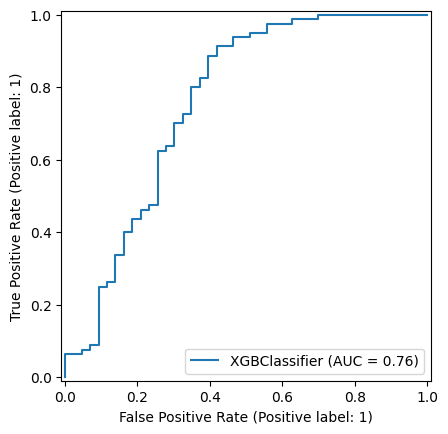

In [49]:
from sklearn.metrics import RocCurveDisplay

RocCurveDisplay.from_estimator(best_xgb, X_test, y_test)
plt.show()

## 17. Feature Importance Plot

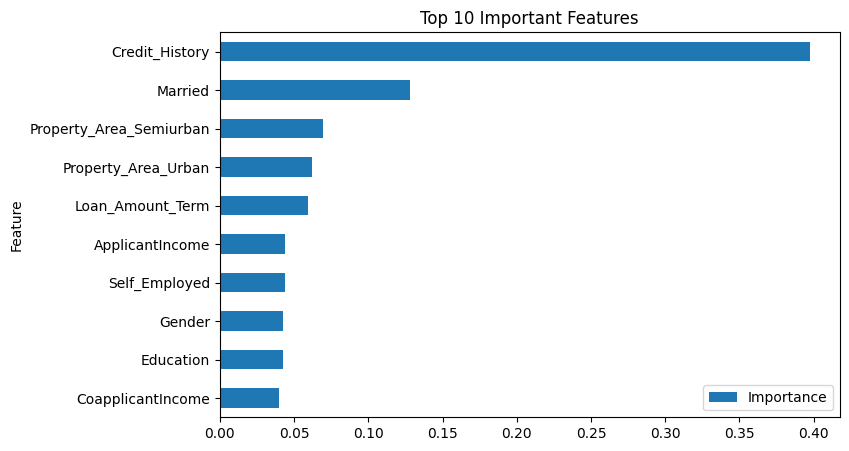

In [50]:
importance.sort_values(
    'Importance',
    ascending=True
).tail(10).plot(
    x='Feature',
    y='Importance',
    kind='barh',
    figsize=(8,5)
)

plt.title("Top 10 Important Features")
plt.show()

## 18. Save Model

In [51]:
import joblib

joblib.dump(best_xgb, "loan_prediction_xgb.pkl")

['loan_prediction_xgb.pkl']

## 19. Conclusion

An XGBoost model was developed for loan approval prediction using data preprocessing, SMOTE oversampling, and hyperparameter tuning. The final model achieved approximately 84% cross-validation accuracy. Credit History emerged as the most influential factor in loan approval decisions, followed by Marital Status and Property Area. The model can assist financial institutions in improving loan screening efficiency and reducing lending risk.